<a href="https://colab.research.google.com/github/Pragzz05/Heart-Disease-Prediction-using-Multiple-Machine-Learning-Algorithms/blob/main/models/SVM_70_30.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Step 1: Importing Required Libraries**

In [ ]:
#Load necessary libraries for data handling and model building.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

**Step 2: Loading the Heart Disease Dataset**

In [ ]:
# Import the dataset into the environment.

df = pd.read_csv('/content/HeartDiseaseTrain-Test.csv')
print(df.head())

   age     sex chest_pain_type  resting_blood_pressure  cholestoral  \
0   52    Male  Typical angina                     125          212   
1   53    Male  Typical angina                     140          203   
2   70    Male  Typical angina                     145          174   
3   61    Male  Typical angina                     148          203   
4   62  Female  Typical angina                     138          294   

      fasting_blood_sugar               rest_ecg  Max_heart_rate  \
0    Lower than 120 mg/ml  ST-T wave abnormality             168   
1  Greater than 120 mg/ml                 Normal             155   
2    Lower than 120 mg/ml  ST-T wave abnormality             125   
3    Lower than 120 mg/ml  ST-T wave abnormality             161   
4  Greater than 120 mg/ml  ST-T wave abnormality             106   

  exercise_induced_angina  oldpeak        slope vessels_colored_by_flourosopy  \
0                      No      1.0  Downsloping                           Two   
1 

**Step 3: Data Preprocessing**

In [ ]:
# Clean and prepare the dataset.

print(df.isnull().sum())

df.columns = df.columns.str.strip()


age                              0
sex                              0
chest_pain_type                  0
resting_blood_pressure           0
cholestoral                      0
fasting_blood_sugar              0
rest_ecg                         0
Max_heart_rate                   0
exercise_induced_angina          0
oldpeak                          0
slope                            0
vessels_colored_by_flourosopy    0
thalassemia                      0
target                           0
dtype: int64


**Step 4: Feature Selection and Encoding**

In [ ]:

# Separate features and apply encoding.

X = df.drop('target', axis=1)
y = df['target']

# One-hot encoding BEFORE split (better practice)
X = pd.get_dummies(X, drop_first=True)

**Step 5: Data Splitting**

In [ ]:
# Split dataset into training and testing sets.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

**Step 6: Feature Scaling**

In [ ]:

#Scale features (VERY IMPORTANT for SVM).

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Step 7: Model Training using SVM**

In [ ]:
#Train SVM with different kernels.

kernels = ['linear', 'poly', 'rbf', 'sigmoid']
results = {}

for kernel in kernels:
    model = SVC(kernel=kernel, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    results[kernel] = acc

**Step 8: Results Comparison**

In [ ]:
#Compare accuracy for different kernels.

for kernel in results:
    print(f"{kernel.upper()} Kernel Accuracy: {results[kernel]}")

LINEAR Kernel Accuracy: 0.814935064935065
POLY Kernel Accuracy: 0.9188311688311688
RBF Kernel Accuracy: 0.8928571428571429
SIGMOID Kernel Accuracy: 0.801948051948052


**Step 9: Final Model Evaluation (Best Kernel Example: RBF)**

Final Accuracy: 0.8928571428571429

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.89      0.90       159
           1       0.88      0.90      0.89       149

    accuracy                           0.89       308
   macro avg       0.89      0.89      0.89       308
weighted avg       0.89      0.89      0.89       308



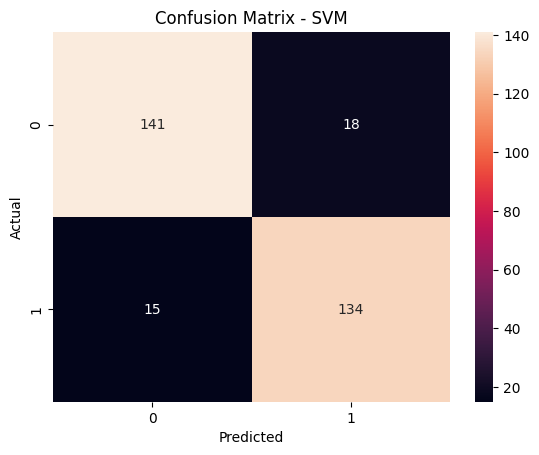

In [ ]:
#Evaluate model performance.

model = SVC(kernel='rbf', random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Final Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")
plt.show()

**Step 10: SAmple Prediction (new Patient)**

In [ ]:
# Example patient data (numeric values as per dataset)

sample_values = {
    'age': 52,
    'sex': 1,
    'chest_pain_type': 2,
    'resting_blood_pressure': 125,
    'cholestoral': 212,
    'fasting_blood_sugar': 0,
    'rest_ecg': 1,
    'Max_heart_rate': 168,
    'exercise_induced_angina': 0,
    'oldpeak': 1.0,
    'slope': 2,
    'vessels_colored_by_flourosopy': 2,
    'thalassemia': 3
}

# Convert to DataFrame
sample_df = pd.DataFrame([sample_values])

# Apply same encoding
sample_df = pd.get_dummies(sample_df, drop_first=True)

# Align columns with training data
sample_df = sample_df.reindex(columns=X.columns, fill_value=0)

# Apply scaling
sample_scaled = scaler.transform(sample_df)

# Predict
prediction = model.predict(sample_scaled)

# Output result
if prediction[0] == 1:
    print("The person is likely to have Heart Disease")
else:
    print("The person is NOT likely to have Heart Disease")

The person is likely to have Heart Disease
